In [1]:
import edn_popdyn.paths
from edn_popdyn.paths import (
    DATA_ROOT, POP_MAT_ROOT, PCA_ROOT,
    FIGURES_DIR, STATS_CSV_DIR,
)

In [2]:
from edn_popdyn import colors as pal

# 4.1 — Expectation and population geometry

Error geometry, pre-target NC-vs-cue centroid separation, held-out task-potent axis, and trial-by-trial geometry predicting reaction time.

## 0) Imports

In [3]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import re
import statsmodels.formula.api as smf

from collections import Counter
from joblib import delayed, Parallel
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
from scipy.stats import gaussian_kde, spearmanr, t as tdist, ttest_1samp, ttest_rel, wilcoxon
from sklearn.linear_model import LogisticRegression
from edn_popdyn import colors as pal

import warnings
warnings.filterwarnings("ignore")

In [4]:
ERR_DARK  = pal.err_dark
ERR_LIGHT = pal.err_light
cue_color = pal.cue       
NC_color  = pal.no_cue    


def _despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

out_dir = f"{FIGURES_DIR}"
os.makedirs(out_dir, exist_ok=True)

## 1) numpy pickle compatibility 

In [5]:
import sys, importlib, importlib.abc, importlib.machinery

class _NumpyCoreRedirect(importlib.abc.MetaPathFinder, importlib.abc.Loader):
    PREFIX = "numpy._core"

    def find_spec(self, fullname, path=None, target=None):
        if fullname == self.PREFIX or fullname.startswith(self.PREFIX + "."):
            return importlib.machinery.ModuleSpec(fullname, self)
        return None

    def create_module(self, spec):
        mod = importlib.import_module("numpy.core" + spec.name[len(self.PREFIX):])
        sys.modules[spec.name] = mod
        return mod

    def exec_module(self, module):
        pass

try:
    import numpy._core
    print("numpy._core present; no shim needed (numpy %s)" % __import__("numpy").__version__)
except ModuleNotFoundError:
    if not any(isinstance(f, _NumpyCoreRedirect) for f in sys.meta_path):
        sys.meta_path.insert(0, _NumpyCoreRedirect())
    import numpy.core
    print("Installed numpy._core -> numpy.core redirect (numpy %s)"
          % __import__("numpy").__version__)

numpy._core present; no shim needed (numpy 1.26.4)


## 2) Loader

In [6]:
AREA = "ALL"
base_dir_pop_mat = str(POP_MAT_ROOT)

_inc = pd.read_csv(f"{DATA_ROOT}/included_sessions.csv", dtype={"timestamp": str})
ALLOWED = set(zip(_inc["bird"], _inc["timestamp"]))

print(f"inclusion list: {len(ALLOWED)} sessions, {_inc['bird'].nunique()} birds")
_ts_re = re.compile(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_\d+)')
supported_exts = (".npy", ".npz", ".pkl", ".pickle")

def load_array_file(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".npy":
        return np.load(path, allow_pickle=True)
    if ext == ".npz":
        z = np.load(path, allow_pickle=True)
        keys = list(z.keys())
        return z[keys[0]] if len(keys) == 1 else {k: z[k] for k in keys}
    if ext in (".pkl", ".pickle"):
        return pd.read_pickle(path)
    raise ValueError(f"Unsupported extension: {ext}")

def pick_best_file(file_list):
    if not file_list:
        return None
    preferred = []
    for f in file_list:
        name = os.path.basename(f).lower()
        if ("psth" in name) or ("array" in name) or ("psth" in os.path.dirname(f).lower()):
            preferred.append(f)
    return sorted(preferred)[0] if preferred else sorted(file_list)[0]

def extract_ts(exp_str):
    m = _ts_re.search(exp_str)
    return m.group(1) if m else None

def build_POP_MAT_all_trials_all_dicts(base_dir_pop_mat, allowed=None):
    POP_MAT_all_trials_all_dicts = {}
    if not os.path.isdir(base_dir_pop_mat):
        raise FileNotFoundError(
            f"Area directory not found: {base_dir_pop_mat}\n"
            f"Set AREA to a directory that exists (e.g. 'NCM', 'ALL', 'CMM').")
    for bird_str in sorted(os.listdir(base_dir_pop_mat)):
        bird_path = os.path.join(base_dir_pop_mat, bird_str)
        if not os.path.isdir(bird_path) or not bird_str.startswith("B"):
            continue
        for exp_str in sorted(os.listdir(bird_path)):
            exp_path = os.path.join(bird_path, exp_str)
            if not os.path.isdir(exp_path) or not exp_str.startswith("exp"):
                continue
            ts = extract_ts(exp_str)
            if ts is None:
                continue
            if allowed is not None and (bird_str, ts) not in allowed:
                continue
            dict_name = f"{bird_str}_{exp_str.replace('-', '_')}_dict"
            trial_type_dict = {}
            for item in sorted(os.listdir(exp_path)):
                item_path = os.path.join(exp_path, item)
                if os.path.isdir(item_path):
                    files = [os.path.join(item_path, f) for f in os.listdir(item_path)
                             if os.path.splitext(f)[1].lower() in supported_exts]
                    chosen = pick_best_file(files)
                    if chosen is None:
                        continue
                    try:
                        arr = load_array_file(chosen)
                    except Exception as e:
                        print(f"Skip {chosen}: {e}")
                        continue
                    trial_type_dict[item] = arr
                else:
                    ext = os.path.splitext(item_path)[1].lower()
                    if ext not in supported_exts:
                        continue
                    try:
                        arr = load_array_file(item_path)
                    except Exception as e:
                        print(f"Skip {item_path}: {e}")
                        continue
                    trial_type = os.path.splitext(item)[0]
                    trial_type_dict[trial_type] = arr
            if trial_type_dict:
                POP_MAT_all_trials_all_dicts[dict_name] = trial_type_dict

    _exps = list(POP_MAT_all_trials_all_dicts.keys())
    _birds = sorted({e.split('_', 1)[0] for e in _exps})
    print(f"AREA={AREA!r}: loaded {len(_exps)} sessions across {len(_birds)} birds "
          f"-> {_birds}")
    return POP_MAT_all_trials_all_dicts

POP_MAT_all_trials_all_dicts = build_POP_MAT_all_trials_all_dicts(base_dir_pop_mat, ALLOWED)

inclusion list: 249 sessions, 9 birds
AREA='ALL': loaded 249 sessions across 9 birds -> ['B1170', 'B1188', 'B1244', 'B1248', 'B1276', 'B1426', 'B1432', 'B1593', 'B1595']


## 3) Format

In [7]:
def format_population_dicts_to_neural_trial_dicts(all_trial_dicts, pad_bins=5, strip_pad=True, enforce_float=True):
    neural_trial_dicts = {}
    for exp_name, trial_dict in all_trial_dicts.items():
        exp_out = {}
        for key, arr in trial_dict.items():
            A = np.asarray(arr)
            if A.ndim != 3:
                continue
            A = np.transpose(A, (0, 2, 1))
            if strip_pad and pad_bins and A.shape[1] > 2 * pad_bins:
                A = A[:, pad_bins:-pad_bins, :]
            if enforce_float:
                A = A.astype(np.float32, copy=False)
            exp_out[key] = A
        if len(exp_out) > 0:
            neural_trial_dicts[exp_name] = exp_out
    if len(neural_trial_dicts) == 0:
        raise ValueError("No 3D arrays found.")
    return neural_trial_dicts

neural_trial_dicts = format_population_dicts_to_neural_trial_dicts(
    POP_MAT_all_trials_all_dicts, pad_bins=0, strip_pad=True,
)

## 4) Parsing helpers

In [8]:
def _tokens(key):
    return [tok for tok in re.split(r"[_\s]+", str(key).lower()) if tok]

_strength_re = re.compile(r'^(sL|wL|wR|sR)(?:_|$)', re.IGNORECASE)
_strength_prefix = re.compile(r'^\s*([sw][lr])(?:_|$)', re.IGNORECASE)

def parse_strength(key):
    toks = _tokens(key)
    for tok in toks:
        if tok in ("sl", "wl", "wr", "sr"):
            return tok
    m = _strength_re.match(str(key))
    return m.group(1).lower() if m else None

def parse_strength_prefix(key):
    toks = _tokens(key)
    for tok in toks:
        if tok in ("sl", "wl", "wr", "sr"):
            return tok
    m = _strength_prefix.match(str(key))
    return m.group(1).lower() if m else None

def strength_to_side(s):
    if s is None:
        return None
    s = str(s).lower()
    return "L" if s.endswith("l") else ("R" if s.endswith("r") else None)

def parse_validity(key):
    toks = _tokens(key)
    if "invalid" in toks:
        return "invalid"
    if "valid" in toks:
        return "valid"
    if "nc" in toks or "nocue" in toks or ("no" in toks and "cue" in toks):
        return "NC"
    return "unknown"

def parse_accuracy(key):
    toks = _tokens(key)
    if "correct" in toks:
        return "correct"
    if "incorrect" in toks:
        return "incorrect"
    return "na"

def parse_interp(key):
    parts = [p for p in str(key).split("_") if p]
    for cand in parts:
        if len(cand) == 2 and cand.isalpha() and cand.upper() not in {"NC"} and cand.lower() not in {"sl","wl","wr","sr"}:
            return cand.upper()
    return "NA"

def key_matches_modality(key, modality):
    toks = _tokens(key)
    return str(modality).lower() in toks

def ensure_TN(arr):
    A = np.asarray(arr)
    if A.ndim != 3:
        raise ValueError(f"Expected 3D, got {A.shape}")
    return A


In [9]:
def bird_of(exp):
    return str(exp).split('_', 1)[0]




def _session_n_units(d):
    for key, arr in d.items():
        A = ensure_TN(np.asarray(arr))
        if A.ndim == 3:
            return A.shape[2]
    return 0


# inclusion: keep only sessions with >= MIN_UNITS recorded units
MIN_UNITS = 10
neural_trial_dicts = {exp: d for exp, d in neural_trial_dicts.items()
                      if _session_n_units(d) >= MIN_UNITS}
print("Recording sessions loaded: %d  (>= %d units)" % (len(neural_trial_dicts), MIN_UNITS))

Recording sessions loaded: 249  (>= 10 units)


## 5) Site mapping + subject-level LME

In [10]:
import warnings
# ---- penetration-site mapping + subject-level LME (same convention as other notebooks) ----
_SITE_ROWS = [
    ("B1170", 2190, 1660,  900,   0, "right", "Field L", "2021-04-14", "2021-04-29"),
    ("B1170", 1260, 1070,  800,   0, "left",  "NCM",     "2021-04-08", "2021-04-12"),
    ("B1170", 1260, 1070, 1364,   0, "left",  "NCM",     "2021-04-12", "2021-04-13"),
    ("B1188", 2500,  900, 2250,   0, "right", "CMM",     "2020-11-02", "2020-11-20"),
    ("B1244", 2000, 1790, 2000, -30, "left",  "Field L", "2021-05-08", "2021-05-11"),
    ("B1248", 1770, 1000,  800,  90, "left",  "NCM",     "2021-07-09", "2021-08-13"),
    ("B1248", 1770, 1000, 1700,  90, "left",  "NCM",     "2021-08-26", "2021-09-17"),
    ("B1248",  670, 1490,  900, -30, "left",  "NCM",     "2021-07-02", "2021-07-07"),
    ("B1248", 1770, 1000, 2500,  90, "left",  "NCM",     "2021-09-17", "2021-09-28"),
    ("B1276", 2000, 1000, 2250,   0, "right", "CMM",     "2021-03-11", "2021-03-15"),
    ("B1426", 2100,  960, 2000,   0, "right", "CMM",     "2021-02-01", "2021-02-04"),
    ("B1432", 2500,  800, 2000,   0, "right", "CMM",     "2021-02-25", "2021-03-27"),
    ("B1593", 1100, 2200,  950,   0, "left",  "NCM",     "2021-06-16", "2021-08-20"),
    ("B1593", 1100, 2200, 1650,   0, "left",  "NCM",     "2021-08-20", "2021-09-19"),
    ("B1595", 1300, 1000,  900,   0, "right", "NCM",     "2021-03-31", "2021-04-03"),
    ("B1595", 1170, 1680, 1000,   0, "left",  "NCM",     "2021-04-07", "2021-04-09"),
    ("B1595", 1300, 1000, 1490,   0, "right", "NCM",     "2021-04-03", "2021-04-04"),
]
SITE_DF = pd.DataFrame(_SITE_ROWS, columns=["bird", "AP", "ML", "Depth", "Rotation",
                                            "Hemisphere", "region", "start", "end"])
SITE_DF["start"] = pd.to_datetime(SITE_DF["start"]); SITE_DF["end"] = pd.to_datetime(SITE_DF["end"])
SITE_DF["site_id"] = (SITE_DF["bird"] + "|AP" + SITE_DF["AP"].astype(str)
                      + "|ML" + SITE_DF["ML"].astype(str) + "|D" + SITE_DF["Depth"].astype(str)
                      + "|R" + SITE_DF["Rotation"].astype(str) + "|" + SITE_DF["Hemisphere"])

_date_re = re.compile(r"(\d{4})[-_](\d{2})[-_](\d{2})")

def _session_bird(s):
    return str(s).split("/")[0].split("_")[0]

def _session_date(s):
    m = _date_re.search(str(s))
    return pd.Timestamp("%s-%s-%s" % m.groups()) if m else pd.NaT

def session_site_region(session):
    bird = _session_bird(session); date = _session_date(session)
    rows = SITE_DF[SITE_DF["bird"] == bird]
    if rows.empty: return ("NO_SITE", "unknown")
    if len(rows) == 1:
        r = rows.iloc[0]; return (r.site_id, r.region)
    if pd.isna(date): return ("UNDATED", "unknown")
    hit = rows[(rows["start"] <= date) & (date <= rows["end"])]
    if len(hit) >= 1:
        r = hit.sort_values("start").iloc[-1]; return (r.site_id, r.region)
    mids = rows["start"] + (rows["end"] - rows["start"]) / 2
    r = rows.iloc[int(np.argmin(np.abs((mids - date).dt.total_seconds())))]
    return (r.site_id, r.region)

def add_site_region(df, session_col="session"):
    if df.empty: return df
    df = df.copy()
    sr = list(df[session_col].map(session_site_region))
    df["site_id"] = [a for a, _ in sr]; df["region"] = [b for _, b in sr]
    if "bird" not in df.columns:
        df["bird"] = df[session_col].map(_session_bird)
    return df



def _fit(m):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for meth in ("lbfgs", "bfgs", "cg", "powell"):
            try: return m.fit(reml=True, method=meth, maxiter=400)
            except Exception: pass
    return None

def subject_lme(df, label, verbose=True):
    keep = add_site_region(df.dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
    nbird = keep["bird"].nunique()
    delta_sess = keep["session_valid_mean"] - keep["session_invalid_mean"]
    out = dict(label=label, beta=float(delta_sess.mean()), ci=(np.nan, np.nan), p=np.nan,
               estimable=False, n_birds=nbird, n_sessions=keep["session"].nunique())
    if nbird >= 3:
        long = pd.melt(keep, id_vars=["session", "bird"],
                       value_vars=["session_valid_mean", "session_invalid_mean"],
                       var_name="cr", value_name="value")
        long["condition"] = pd.Categorical(long["cr"].map(
            {"session_valid_mean": "Valid", "session_invalid_mean": "Invalid"}),
            categories=["Invalid", "Valid"])
        m = _fit(smf.mixedlm("value ~ condition", long, groups="bird",
                             vc_formula={"session": "0 + C(session)"}))
        if m is not None:
            k = [x for x in m.fe_params.index if x.startswith("condition")][0]
            ci = m.conf_int().loc[k]
            out.update(beta=float(m.fe_params[k]), ci=(float(ci[0]), float(ci[1])),
                       p=float(m.pvalues[k]), estimable=True)
    if verbose:
        print("=== %s ===" % label)
        if out["estimable"]:
            print("  LME valid-invalid = %+.5f  [%+.5f, %+.5f]  P = %.4g   (%d birds, %d populations)"
                  % (out["beta"], out["ci"][0], out["ci"][1], out["p"], out["n_birds"], out["n_sessions"]))
        else:
            print("  LME not testable (<3 birds / no convergence); mean delta = %+.5f  (%d birds)"
                  % (out["beta"], out["n_birds"]))
    return out

## 6) Task-potent margins (held-out axis)

In [11]:
def _session_trial_table(d, modality='active', pre0=0, pre1=5, stim0=5, stim1=50, t_need=50):
    rows = []
    for key, arr in d.items():
        if not key_matches_modality(key, modality): continue
        side = strength_to_side(parse_strength(key))
        if side not in ('L', 'R'): continue
        v = parse_validity(key); acc = parse_accuracy(key)
        strat = "%s|%s" % (parse_strength(key), parse_interp(key))
        A = ensure_TN(arr)
        for i in range(A.shape[0]):
            tr = np.asarray(A[i], float)
            if tr.ndim != 2 or tr.shape[0] < t_need or not np.isfinite(tr).all(): continue
            x = tr[stim0:stim1].mean(axis=0); x_pre = tr[pre0:pre1].mean(axis=0)
            if not (np.isfinite(x).all() and np.isfinite(x_pre).all()): continue
            rows.append(dict(side=side, validity=v, accuracy=acc, strat=strat, x=x, x_pre=x_pre))
    df = pd.DataFrame(rows)
    if not df.empty:                       # keep the session's majority unit count
        dims = df['x'].apply(lambda a: np.asarray(a).shape[-1])
        df = df[dims == dims.mode().iloc[0]].reset_index(drop=True)
    return df

def _fit_logreg(X, y, C=1.0):
    mu = X.mean(0, keepdims=True)
    clf = LogisticRegression(C=C, solver="liblinear", max_iter=5000, class_weight="balanced")
    clf.fit(X - mu, y)
    return clf, mu.reshape(-1)

def _signed_toward_target(dec, side):
    return dec if side == "R" else -dec

def task_potent_margins(neural_trial_dicts, C=1.0, min_per_class=8, modality='active'):
    lab = {"L": 0, "R": 1}; out = []
    for exp, d in neural_trial_dicts.items():
        df = _session_trial_table(d, modality=modality)
        if df.empty: continue
        nc = df[(df.validity == "NC") & (df.accuracy == "correct")]
        if (nc.side == "L").sum() < min_per_class or (nc.side == "R").sum() < min_per_class: continue
        clf, mu = _fit_logreg(np.stack(nc.x.values), nc.side.map(lab).values, C=C)
        test = df[df.validity != "NC"].copy()
        if test.empty: continue
        dec = clf.decision_function(np.stack(test.x.values) - mu)
        test["margin"] = [_signed_toward_target(dd, s) for dd, s in zip(dec, test.side)]
        test["exp"] = exp
        out.append(test[["side", "validity", "accuracy", "strat", "margin", "exp"]])
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

MARGINS = task_potent_margins(neural_trial_dicts, min_per_class=8, C=1.0)

from collections import Counter as _Counter
_SITE_N = _Counter(session_site_region(s)[0] for s in neural_trial_dicts)
VALID_SITES = {s for s, c in _SITE_N.items() if c >= 2}

PAPER_SUBJECTS = {"B1170", "B1188", "B1244", "B1248", "B1426", "B1432", "B1593"}
def keep_valid_sites(df, session_col="session"):
    d = df[df[session_col].map(lambda s: session_site_region(s)[0]).isin(VALID_SITES)].copy()
    return d[d[session_col].map(_session_bird).isin(PAPER_SUBJECTS)]
print("task-potent margins: %d populations" % MARGINS["exp"].nunique())


def paired_raincloud(a, b, labels, colors, ylabel, p_value=None, out_path=None, seed=0, W=0.35, figsize=(4, 4)):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b); a, b = a[m], b[m]; n = len(a)
    rng = np.random.default_rng(seed); fig, ax = plt.subplots(figsize=figsize)
    for x, d, side, col in [(0, a, -1, colors[0]), (1, b, +1, colors[1])]:
        if len(np.unique(d)) > 1:
            ys = np.linspace(d.min(), d.max(), 200); dn = gaussian_kde(d)(ys); dn = dn / dn.max() * W
            ax.fill_betweenx(ys, x, x + side * dn, color=col, alpha=0.35, edgecolor=col, lw=1)
    xa = 0.10 + rng.uniform(-0.03, 0.03, n); xb = 0.90 + rng.uniform(-0.03, 0.03, n)
    for i in range(n): ax.plot([xa[i], xb[i]], [a[i], b[i]], color="0.6", lw=0.6, alpha=0.4, zorder=1)
    ax.scatter(xa, a, s=42, color=colors[0], edgecolor="white", lw=0.6, zorder=3)
    ax.scatter(xb, b, s=42, color=colors[1], edgecolor="white", lw=0.6, zorder=3)
    ax.plot([0 - W, 0.16], [np.median(a)] * 2, color=colors[0], lw=6, solid_capstyle="round", zorder=4)
    ax.plot([0.84, 1 + W], [np.median(b)] * 2, color=colors[1], lw=6, solid_capstyle="round", zorder=4)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels); ax.set_ylabel(ylabel)
    if p_value is not None:
        ax.text(0.5, 0.98, f"p = {p_value:.2g}", transform=ax.transAxes, ha="center", va="top", fontsize=10)
    ax.legend(handles=[mpatches.Patch(color=colors[0], label=labels[0]),
                       mpatches.Patch(color=colors[1], label=labels[1])],
              loc="lower right", fontsize=8, frameon=False, handlelength=1.0)
    _despine(ax); fig.tight_layout()
    if out_path: fig.savefig(out_path, bbox_inches="tight")
    plt.show(); return fig, ax

def delta_raincloud(a, b, pos_color, neg_color, pos_name, neg_name, ylabel, pos_label="",
                    title="", out_path=None, seed=0, width=0.34, figsize=(3.2, 4.2)):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b); d = (a - b)[m]
    n = len(d); n_above = int((d > 0).sum()); W, p = wilcoxon(d, alternative="greater")
    pad = 0.12 * (d.max() - d.min() + 1e-9); ys = np.linspace(d.min() - pad, d.max() + pad, 300)
    dens = gaussian_kde(d)(ys); dens = dens / dens.max() * width
    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color=pal.gray_mid, lw=1, ls="--", zorder=0)
    ax.fill_betweenx(ys[ys >= 0], 0, dens[ys >= 0], color=pos_color, alpha=0.40, lw=0)
    ax.fill_betweenx(ys[ys < 0], 0, dens[ys < 0], color=neg_color, alpha=0.40, lw=0)
    ax.plot(dens, ys, color="k", lw=0.8)
    rng = np.random.default_rng(seed); jx = -0.07 - rng.random(n) * 0.13
    ax.scatter(jx, d, s=22, c=[pos_color if x > 0 else neg_color for x in d], edgecolor="k", linewidth=0.3, zorder=3)
    ax.hlines(np.median(d), -0.02, dens.max(), color="k", lw=2, zorder=4)
    ax.set_xticks([]); ax.set_xlim(-0.24, width + 0.05); ax.set_ylabel(ylabel)
    if title: ax.set_title(title, fontsize=9)
    ax.legend(handles=[mpatches.Patch(color=pos_color, label=pos_name),
                       mpatches.Patch(color=neg_color, label=neg_name)],
              loc="lower right", fontsize=8, frameon=False, handlelength=1.0)
    _despine(ax); fig.tight_layout()
    if out_path: fig.savefig(out_path, bbox_inches="tight")
    plt.show(); return fig, ax

task-potent margins: 207 populations


## 7) Directional shift: valid vs invalid

per-bird populations: {'B1170': 32, 'B1188': 10, 'B1244': 2, 'B1248': 55, 'B1426': 1, 'B1432': 42, 'B1593': 63}
=== valid vs invalid ===
  LME valid-invalid = +0.04667  [+0.03052, +0.06282]  P = 1.476e-08   (7 birds, 205 populations)


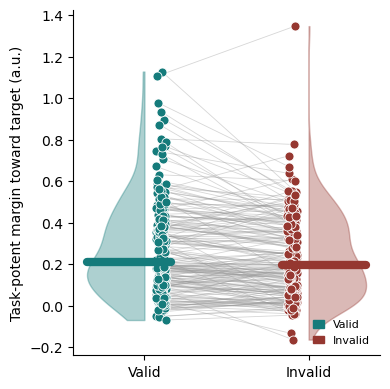

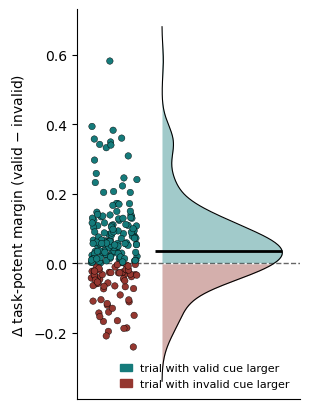

In [12]:
def directional_shift_summary(margins, min_per_class=8, stratum_balanced=True):
    out = []
    for exp, g in margins.groupby("exp"):
        g = g[g.accuracy == "correct"]
        val = g[g.validity == "valid"]; inv = g[g.validity == "invalid"]
        if len(val) < min_per_class or len(inv) < min_per_class: continue
        if stratum_balanced:
            shared = sorted(set(val.strat) & set(inv.strat))
            if not shared: continue
            mv = np.nanmean([val[val.strat == s]["margin"].mean() for s in shared])
            mi = np.nanmean([inv[inv.strat == s]["margin"].mean() for s in shared])
        else:
            mv, mi = float(val["margin"].mean()), float(inv["margin"].mean())
        out.append(dict(session=exp, bird=bird_of(exp),
                        session_valid_mean=float(mv), session_invalid_mean=float(mi)))
    return pd.DataFrame(out)

ds = directional_shift_summary(MARGINS, min_per_class=8, stratum_balanced=True)
ds = keep_valid_sites(ds, "session")          # sites with >= 2 recorded sessions (2.2-style)
print("per-bird populations:", ds["bird"].value_counts().sort_index().to_dict())
r_dir = subject_lme(ds, "valid vs invalid")   # subject-level LME (valid - invalid)

a = ds["session_valid_mean"]; b = ds["session_invalid_mean"]
paired_raincloud(a, b, labels=("Valid", "Invalid"), colors=(pal.valid, pal.invalid),
                 ylabel="Task-potent margin toward target (a.u.)",
                 out_path=os.path.join(out_dir, "directional_shift_paired_raincloud.svg"))
delta_raincloud(a, b, pal.valid, pal.invalid,
                pos_name="trial with valid cue larger", neg_name="trial with invalid cue larger",
                ylabel=r"$\Delta$ task-potent margin (valid $-$ invalid)",
                out_path=os.path.join(out_dir, "directional_shift_delta_raincloud.svg"))
ds.to_csv(os.path.join(out_dir, "directional_shift.csv"), index=False)

## 8) Decoding errors: incorrect vs correct

incorrect vs correct | n_pop=205, n_birds=7
  LME (incorrect-correct): beta=+0.0946  [+0.0755, +0.1138]  p=3.96e-22
  Wilcoxon (incorrect>correct): p=3.21e-19


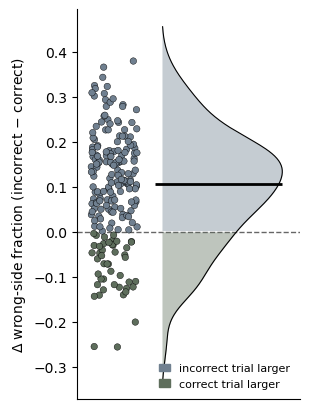

In [13]:
def error_wrongside_summary(margins, min_per_class=3):
    out = []
    for exp, g in margins.groupby("exp"):
        c = g[g.accuracy == "correct"]["margin"].to_numpy(float); c = c[np.isfinite(c)]
        i = g[g.accuracy == "incorrect"]["margin"].to_numpy(float); i = i[np.isfinite(i)]
        if len(c) < min_per_class or len(i) < min_per_class: continue
        out.append(dict(exp=exp, bird=bird_of(exp),
                        frac_wrong_correct=float(np.mean(c < 0)),
                        frac_wrong_incorrect=float(np.mean(i < 0)),
                        delta=float(np.mean(i < 0) - np.mean(c < 0)),
                        median_margin_correct=float(np.median(c)),
                        median_margin_incorrect=float(np.median(i))))
    return pd.DataFrame(out)

df_dec_sess = error_wrongside_summary(MARGINS)   
df_dec_sess = keep_valid_sites(df_dec_sess, "exp")   

_long = pd.concat([
    pd.DataFrame(dict(bird=df_dec_sess["bird"], frac=df_dec_sess["frac_wrong_correct"],   accuracy="correct")),
    pd.DataFrame(dict(bird=df_dec_sess["bird"], frac=df_dec_sess["frac_wrong_incorrect"], accuracy="incorrect")),
], ignore_index=True)
_long["accuracy"] = pd.Categorical(_long["accuracy"], categories=["correct", "incorrect"])
_m = smf.mixedlm("frac ~ accuracy", _long, groups=_long["bird"]).fit(reml=True, method="lbfgs")
_c = "accuracy[T.incorrect]"; _b = _m.params[_c]; _se = _m.bse[_c]; _p = _m.pvalues[_c]
_dd = (df_dec_sess["frac_wrong_incorrect"] - df_dec_sess["frac_wrong_correct"]).to_numpy()
_W, _pw = wilcoxon(_dd, alternative="greater")
print("incorrect vs correct | n_pop=%d, n_birds=%d" % (df_dec_sess["exp"].nunique(), df_dec_sess["bird"].nunique()))
print("  LME (incorrect-correct): beta=%+.4f  [%+.4f, %+.4f]  p=%.3g" % (_b, _b-1.96*_se, _b+1.96*_se, _p))
print("  Wilcoxon (incorrect>correct): p=%.3g" % _pw)

delta_raincloud(df_dec_sess["frac_wrong_incorrect"], df_dec_sess["frac_wrong_correct"],
                pos_color="slategray", neg_color=pal.correct_dark, pos_name="incorrect trial larger", neg_name="correct trial larger",
                ylabel=r"$\Delta$ wrong-side fraction (incorrect $-$ correct)", pos_label="incorrect > correct",
                out_path=os.path.join(out_dir, "errors_delta_raincloud.svg"))
df_dec_sess.to_csv(os.path.join(out_dir, "errors_wrongside.csv"), index=False)

## 9) Pre-target centroid geometry


In [14]:
def _featurize_pre(trial_TN, t0=5, mode="mean", zscore_within_trial=True):
    X = np.asarray(trial_TN)[:t0, :]
    if zscore_within_trial:
        X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-9)
    if mode == "flatten":
        return X.reshape(-1)
    if mode == "mean":
        return X.mean(axis=0)
    raise ValueError("mode must be 'flatten' or 'mean'")

def _build_pre_df(
    neural_trial_dicts,
    t0=5,
    modality="active",
    accuracy="correct",
    keep_validities=("valid", "NC"),
    T_need=60,
    mode="mean",
    zscore_within_trial=True,
):
    rows = []
    for exp, d in neural_trial_dicts.items():
        for key, arr in d.items():
            if not key_matches_modality(key, modality):
                continue
            acc = parse_accuracy(key)
            if accuracy is not None and acc != accuracy:
                continue
            v = parse_validity(key)
            if v not in keep_validities:
                continue
            s = parse_strength_prefix(key)
            side = strength_to_side(s)
            if side not in ("L", "R"):
                continue
            cue_group = "NC" if v == "NC" else ("cue1" if side == "R" else "cue2")
            A = ensure_TN(arr)
            if A.shape[1] < T_need:
                continue
            for i in range(A.shape[0]):
                tr = A[i]
                if tr.shape[0] < T_need or (not np.isfinite(tr).all()):
                    continue
                f = _featurize_pre(tr, t0=t0, mode=mode, zscore_within_trial=zscore_within_trial)
                rows.append(dict(exp=exp, cue_group=cue_group, feat=f))
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No trials after filtering.")
    return df

def session_level_centroid_geometry(
    neural_trial_dicts,
    t0=5,
    modality="active",
    accuracy="correct",
    keep_validities=("valid", "NC"),
    T_need=60,
    mode="mean",
    zscore_within_trial=True,
    min_trials_per_group=10,
    eps=1e-12,
    verbose=True,
):
    df = _build_pre_df(neural_trial_dicts, t0=t0, modality=modality, accuracy=accuracy,
                       keep_validities=keep_validities, T_need=T_need, mode=mode,
                       zscore_within_trial=zscore_within_trial)
    out = []
    for exp, g in df.groupby("exp"):
        cts = g["cue_group"].value_counts()
        if (cts.get("cue1", 0) < min_trials_per_group or
            cts.get("cue2", 0) < min_trials_per_group or
            cts.get("NC",   0) < min_trials_per_group):
            continue
        X1 = np.stack(g[g["cue_group"] == "cue1"]["feat"].values, axis=0)
        X2 = np.stack(g[g["cue_group"] == "cue2"]["feat"].values, axis=0)
        XN = np.stack(g[g["cue_group"] == "NC"]["feat"].values, axis=0)
        mu1, mu2, muN = X1.mean(0), X2.mean(0), XN.mean(0)
        mid = 0.5 * (mu1 + mu2)
        d12 = float(np.linalg.norm(mu2 - mu1))
        dNm = float(np.linalg.norm(muN - mid))
        out.append({
            "exp": exp,
            "dist_cue1_cue2": d12,
            "dist_NC_mid":    dNm,
            "ratio":          dNm / (d12 + eps),
            "delta":          dNm - d12,
            "n_cue1": int(cts.get("cue1", 0)),
            "n_cue2": int(cts.get("cue2", 0)),
            "n_NC":   int(cts.get("NC", 0)),
        })
    df_sess = pd.DataFrame(out)
    if df_sess.empty:
        raise ValueError("No sessions survived min_trials_per_group.")
    if verbose:
        print(f"Sessions kept: {len(df_sess)}")
    return df_sess


In [15]:
df_geom_sess = session_level_centroid_geometry(
    neural_trial_dicts,
    t0=5, modality="active", accuracy="correct",
    keep_validities=("valid", "NC"), T_need=60, mode="mean",
    zscore_within_trial=True, min_trials_per_group=10,
)
df_geom_sess.to_csv(os.path.join(out_dir, "ratio_session_data.csv"), index=False)

# subject-level LME (same convention): distance NC-to-midpoint vs cue1-cue2
_geom = df_geom_sess.rename(columns={"exp": "session",
                                     "dist_NC_mid": "session_valid_mean",
                                     "dist_cue1_cue2": "session_invalid_mean"})
_geom = keep_valid_sites(_geom, "session")       # sites with >= 2 recorded sessions (2.2-style)
_rg = subject_lme(_geom, "centroid", verbose=False)
print("NC-to-mid vs cue1-cue2 distance | n_pop=%d, n_birds=%d" % (_rg["n_sessions"], _rg["n_birds"]))
print("  LME (NC-mid - cue): beta=%+.5f  [%+.5f, %+.5f]  p=%.3g"
      % (_rg["beta"], _rg["ci"][0], _rg["ci"][1], _rg["p"]))

Sessions kept: 208
NC-to-mid vs cue1-cue2 distance | n_pop=207, n_birds=7
  LME (NC-mid - cue): beta=+0.00000  [+0.00000, +0.00000]  p=1.21e-09


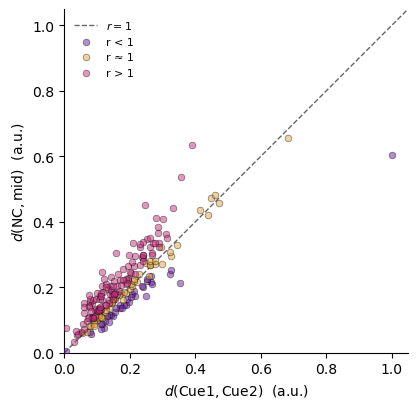

In [16]:
def plot_centroid_scatter_by_r(df_sess, figsize=(4.6, 4.2), tol=0.10):
    d12 = df_sess["dist_cue1_cue2"].to_numpy(float)
    dNm = df_sess["dist_NC_mid"].to_numpy(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        r = dNm / d12
    scale = max(d12.max(), dNm.max())
    d12n, dNmn = d12 / scale, dNm / scale
    masks = {"r < 1": r < 1 - tol, "r ≈ 1": (r >= 1 - tol) & (r <= 1 + tol), "r > 1": r > 1 + tol}
    cols = {"r < 1": pal.ratio_low, "r ≈ 1": pal.ratio_mid, "r > 1": pal.ratio_high}
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1.05], [0, 1.05], color=pal.gray_mid, lw=1, ls="--", label=r"$r = 1$")
    for lab, m in masks.items():
        m = m & np.isfinite(d12n) & np.isfinite(dNmn)
        if m.any():
            ax.scatter(d12n[m], dNmn[m], s=23, color=cols[lab], edgecolor="k",
                       linewidth=0.5, alpha=0.5, zorder=3, label=lab)
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ticks = np.arange(0, 1.01, 0.2); ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.set_xlabel(r"$d(\mathrm{Cue1},\mathrm{Cue2})$  (a.u.)")
    ax.set_ylabel(r"$d(\mathrm{NC},\mathrm{mid})$  (a.u.)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    _despine(ax); fig.tight_layout()
    return fig, ax

fig, _ = plot_centroid_scatter_by_r(df_geom_sess, tol=0.10)
fig.savefig(os.path.join(out_dir, "ratio_scatter_by_r.svg"), format="svg", bbox_inches="tight")
plt.show()

## 10) Distance from pre-target subspace


In [17]:
# ===== Distance from the pre-target subspace: cued vs no-cue (definitions) =====
CUED_C, UNCUED_C = "black", "0.55"

def strength_to_level(s):
    return None if s is None else s[0].lower()

def _trial_mean_vectors(trials, t0, t1):
    vecs = []
    for tr in trials:
        tr = np.asarray(tr)
        if tr.shape[0] < t1:
            continue
        x = tr[t0:t1].mean(axis=0)
        if np.isfinite(x).all():
            vecs.append(x)
    return None if not vecs else np.stack(vecs, axis=0)

def _pca_subspace(X, k=3):
    X = np.asarray(X, float); Xc = X - X.mean(0, keepdims=True); Xc[~np.isfinite(Xc)] = 0.0
    try:
        _, _, VT = np.linalg.svd(Xc, full_matrices=False)
    except np.linalg.LinAlgError:
        return None
    V = VT.T; k_eff = min(k, V.shape[1])
    if k_eff <= 0:
        return None
    Q, _ = np.linalg.qr(V[:, :k_eff]); return Q[:, :k_eff]

def distance_timecourse(neural_trial_dicts, modality, accuracy,
                        pre0=0, pre1=5, stim0=5, T_total=60, k_sub=3,
                        min_trials_per_group=5, step=2, n_jobs=8):
    """Per session×group time-course of distance from the pre-target 3-D subspace,
    normalized by baseline dispersion. Cued = valid+invalid; NC = no cue."""
    rows = []
    for exp, d in neural_trial_dicts.items():
        for key, arr in d.items():
            if not key_matches_modality(key, modality):
                continue
            v = parse_validity(key)
            if v not in ("valid", "invalid", "NC"):
                continue
            acc = parse_accuracy(key)
            if v in ("valid", "invalid") and accuracy is not None and acc != accuracy:
                continue
            if v == "NC" and accuracy is not None and acc not in (accuracy, "na"):
                continue
            level = strength_to_level(parse_strength_prefix(key))
            if level not in ("s", "w"):
                continue
            group = "cued" if v in ("valid", "invalid") else "NC"
            A = ensure_TN(arr)
            for i in range(A.shape[0]):
                tr = A[i]
                if tr.shape[0] < T_total or not np.isfinite(tr).all():
                    continue
                rows.append(dict(exp=exp, level=level, group=group, trial=np.asarray(tr, float)))
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No trials after filtering.")
    grid = list(range(stim0 + 1, T_total + 1, step))
    if grid[-1] != T_total:
        grid.append(T_total)

    def one_group(exp, group, g):
        trials = list(g["trial"].values)
        if len(trials) < min_trials_per_group:
            return None
        Xpre = _trial_mean_vectors(trials, pre0, pre1)
        if Xpre is None:
            return None
        mu_pre = Xpre.mean(0); Q = _pca_subspace(Xpre, k=k_sub)
        if Q is None:
            return None
        scale = np.nanmedian(np.linalg.norm(Xpre - mu_pre[None, :], axis=1))
        if not np.isfinite(scale) or scale < 1e-6:
            scale = 1.0
        d_bins, t_bins = [], []
        for t_end in grid:
            Xs = _trial_mean_vectors(trials, stim0, t_end)
            if Xs is None:
                continue
            z = Xs.mean(0) - mu_pre; z_hat = Q @ (Q.T @ z)
            d_bins.append(float(np.linalg.norm(z - z_hat)) / scale); t_bins.append(t_end - 1)
        if not d_bins:
            return None
        dist = np.full(T_total, np.nan); dist[:stim0 + 1] = 0.0
        xq = np.arange(min(t_bins), max(t_bins) + 1)
        dist[xq] = np.interp(xq, t_bins, d_bins)
        return dict(exp=exp, group=group, dist_time=dist)

    res = Parallel(n_jobs=n_jobs, prefer="processes")(
        delayed(one_group)(exp, group, g)
        for (exp, level, group), g in df.groupby(["exp", "level", "group"]))
    df_tc = pd.DataFrame([r for r in res if r is not None])
    if df_tc.empty:
        raise ValueError("df_tc empty.")
    return df_tc, np.arange(T_total)

def _collapse_to_session(df_tc, value_col="dist_time"):
    rows = []
    for (exp, group), g in df_tc.groupby(["exp", "group"]):
        curves = np.stack(list(g[value_col].values), 0)
        rows.append({"exp": exp, "group": group, value_col: np.nanmean(curves, 0)})
    return pd.DataFrame(rows)

def plot_distance(df_tc, times, title, ylabel="Distance from pre-target subspace (a.u.)",
                  t_gray0=5, t_gray1=55, ms_per_bin=20, start_ms=-100, figsize=(7, 4)):
    df_sess = _collapse_to_session(df_tc)
    pairs = []
    for exp, g in df_sess.groupby("exp"):
        gc = g[g["group"] == "cued"]; gn = g[g["group"] == "NC"]
        if len(gc) and len(gn):
            pairs.append((exp, gc.iloc[0]["dist_time"], gn.iloc[0]["dist_time"]))
    if not pairs:
        raise ValueError("No sessions with both cued and NC.")
    C = np.stack([p[1] for p in pairs], 0); N = np.stack([p[2] for p in pairs], 0)
    mc, mn = np.nanmean(C, 0), np.nanmean(N, 0)
    sem_c = np.nanstd(C, 0, ddof=1) / np.sqrt(np.maximum(np.sum(np.isfinite(C), 0), 1))
    sem_n = np.nanstd(N, 0, ddof=1) / np.sqrt(np.maximum(np.sum(np.isfinite(N), 0), 1))
    t = start_ms + np.asarray(times) * ms_per_bin
    fig, ax = plt.subplots(figsize=figsize)
    ax.axvspan(start_ms + t_gray0 * ms_per_bin, start_ms + t_gray1 * ms_per_bin, color="grey", alpha=0.18, lw=0)
    ax.fill_between(t, mc - sem_c, mc + sem_c, color=CUED_C, alpha=0.12, lw=0)
    ax.fill_between(t, mn - sem_n, mn + sem_n, color=UNCUED_C, alpha=0.20, lw=0)
    ax.plot(t, mc, lw=2, color=CUED_C, ls="-", label="Cued (valid+invalid)")
    ax.plot(t, mn, lw=2, color=UNCUED_C, ls="--", label="No cue")
    ax.set_xlabel("Time (ms)"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xlim(t[0], t[-1]); ax.legend(frameon=False, loc="upper left")
    _despine(ax); ax.grid(False); fig.tight_layout()
    return fig, ax, pairs

def paired_lme(pairs, window=(5, 55), label=""):
    """Session-level paired LME of (cued − NC) mean distance over the window."""
    t0, t1 = window
    recs = [dict(session=exp, bird=bird_of(exp),
                 delta=float(np.nanmean(c[t0:t1]) - np.nanmean(n[t0:t1])))
            for (exp, c, n) in pairs]
    df = keep_valid_sites(pd.DataFrame(recs).dropna(subset=["delta"]), "session")
    if df["bird"].nunique() < 2:
        raise ValueError(f"[{label}] need >=2 birds.")
    method = "LME (1|bird)"
    try:
        fit = smf.mixedlm("delta ~ 1", df, groups=df["bird"]).fit(reml=False, method="lbfgs")
        beta = float(fit.fe_params["Intercept"]); se = float(fit.bse["Intercept"])
        p = float(fit.pvalues["Intercept"]); ci = fit.conf_int().loc["Intercept"]
        lo, hi = float(ci[0]), float(ci[1])
    except Exception:
        se = np.nan; beta = float(df["delta"].mean()); p = np.nan; lo = hi = np.nan
    if (not np.isfinite([se, p, lo]).all()) or se > 1.0:            # degenerate RE -> bird-mean t
        bm = df.groupby("bird")["delta"].mean().to_numpy(); nb = len(bm)
        beta = float(bm.mean()); se = float(bm.std(ddof=1) / np.sqrt(nb))
        _, p = ttest_1samp(bm, 0.0); p = float(p)
        crit = float(tdist.ppf(0.975, nb - 1)); lo, hi = beta - crit * se, beta + crit * se
        method = "bird-mean t (RE var ~0)"
    print("[%s] cued-NC: beta=%+.4g [%+.4g, %+.4g]  p=%.4g | n_pops=%d n_birds=%d"
          % (label, beta, lo, hi, p, df["session"].nunique(), df["bird"].nunique()))
    return dict(beta=beta, ci=(lo, hi), p=p, method=method,
                n_pops=int(df["session"].nunique()), n_birds=int(df["bird"].nunique()))

def _long_from_pairs(pairs, modality, window=(5, 55)):
    t0, t1 = window; rows = []
    for (exp, c, n) in pairs:
        b = bird_of(exp)
        rows.append(dict(exp=exp, bird=b, group="cued", modality=modality, dist=float(np.nanmean(c[t0:t1]))))
        rows.append(dict(exp=exp, bird=b, group="NC",   modality=modality, dist=float(np.nanmean(n[t0:t1]))))
    return pd.DataFrame(rows)

def cue_modality_interaction(pairs_active, pairs_passive, window=(5, 55)):
    """cue × modality interaction on populations recorded under both modalities."""
    df = pd.concat([_long_from_pairs(pairs_active, "active", window),
                    _long_from_pairs(pairs_passive, "passive", window)], ignore_index=True).dropna(subset=["dist"])
    keep = [e for e, g in df.groupby("exp") if g.groupby(["group", "modality"]).ngroups == 4]
    df2 = keep_valid_sites(df[df["exp"].isin(keep)].copy(), "exp")
    if df2["exp"].nunique() == 0:
        print("cue x modality interaction: not testable"); return None
    df2["group"] = pd.Categorical(df2["group"], categories=["NC", "cued"])
    df2["modality"] = pd.Categorical(df2["modality"], categories=["active", "passive"])
    m = smf.mixedlm("dist ~ C(group)*C(modality)", df2, groups="bird",
                    vc_formula={"session": "0 + C(exp)"}).fit(reml=False, method="lbfgs")
    k = [x for x in m.fe_params.index if ":" in x][0]
    print("cue x modality interaction: beta=%+.4g  p=%.4g | n_pops=%d n_birds=%d"
          % (m.fe_params[k], m.pvalues[k], df2["exp"].nunique(), df2["bird"].nunique()))
    return m

[active] cued-NC: beta=-0.04509 [-0.2886, +0.1984]  p=0.7166 | n_pops=207 n_birds=7
[passive] cued-NC: beta=+0.0022 [-0.04588, +0.05028]  p=0.9285 | n_pops=117 n_birds=6


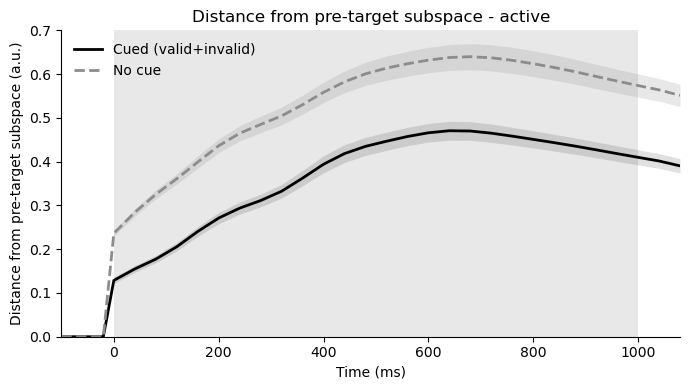

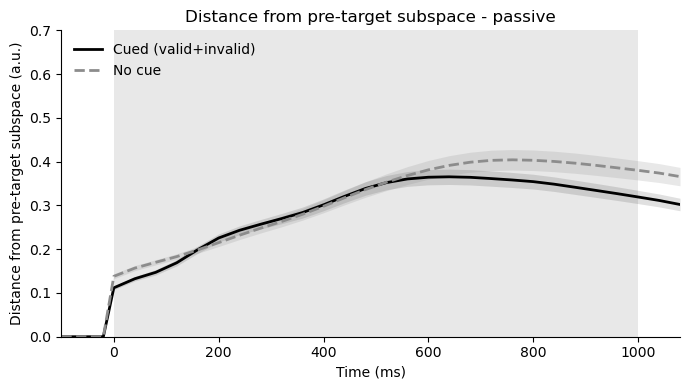

cue x modality interaction: beta=+0.256  p=1.96e-16 | n_pops=96 n_birds=5


In [18]:
df_tc_active, times = distance_timecourse(neural_trial_dicts, modality="active", accuracy="correct")
fig_da, ax_da, pairs_da = plot_distance(df_tc_active, times, "Distance from pre-target subspace - active")
lme_da = paired_lme(pairs_da, window=(5, 55), label="active")

df_tc_passive, times = distance_timecourse(neural_trial_dicts, modality="passive", accuracy=None)
fig_dp, ax_dp, pairs_dp = plot_distance(df_tc_passive, times, "Distance from pre-target subspace - passive")
lme_dp = paired_lme(pairs_dp, window=(5, 55), label="passive")

for ax in (ax_da, ax_dp):
    ax.set_ylim(0, 0.7); ax.set_xlim(ax_da.get_xlim())
fig_da.savefig(os.path.join(out_dir, "dist_active.svg"),  bbox_inches="tight")
fig_dp.savefig(os.path.join(out_dir, "dist_passive.svg"), bbox_inches="tight")
plt.show()

cue_modality_interaction(pairs_da, pairs_dp, window=(5, 55))

## 11) Trial-by-trial pre-target geometry predicts RT

Three pre-target stability metrics, each tested at the trial level:
- `peak_dist_from_pre_subspace` (headline; matches H/I)
- `pre_var` (supplementary)
- `dist_from_centroid` (supplementary)

For each metric: continuous correlation plot (within-session z-scored,
pooled, binned mean ± SEM). No paired strip plot here -- the cue vs NC
contrast is already shown in panels H/I.

In [19]:
def _find_exp_dir(base_dir_pop_mat, bird, exp_key):
    bird_path = os.path.join(base_dir_pop_mat, bird)
    if not os.path.isdir(bird_path): return None
    for d in sorted(os.listdir(bird_path)):
        m = _ts_re.search(d)
        if m and m.group(1).replace('-', '_') in exp_key:
            return os.path.join(bird_path, d)
    return None


def per_trial_pretarget_stability(
    neural_trial_dicts, base_dir_pop_mat,
    modality='active', accuracy='correct',
    pre0=0, pre1=5, t0=5, t1=50, k_pre=3,
    keep_validities=('valid', 'invalid', 'NC'),
    min_rt=0.05, max_rt=5.0, verbose=True,
):
    rows = {k: [] for k in ('exp', 'bird', 'key', 'validity', 'cue_present',
                            'rt', 'log_rt', 'dist_from_centroid', 'pre_var',
                            'peak_dist_from_pre_subspace')}
    for exp, d in neural_trial_dicts.items():
        bird = exp.split('_', 1)[0]
        exp_dir = _find_exp_dir(base_dir_pop_mat, bird, exp)
        if exp_dir is None:
            continue
        Ns = [np.asarray(a).shape[2] for a in d.values()
              if np.asarray(a).ndim == 3 and np.asarray(a).shape[1] >= t1]
        if not Ns:
            continue
        ref_N = Counter(Ns).most_common(1)[0][0]

        def _ok(A):
            return A.ndim == 3 and A.shape[1] >= t1 and A.shape[2] == ref_N

        pre_chunks_all = []
        for key, arr in d.items():
            A = ensure_TN(arr)
            if not _ok(A):
                continue
            pw = A[:, pre0:pre1, :].mean(axis=1)
            pre_chunks_all.append(pw[np.isfinite(pw).all(axis=1)])
        if not pre_chunks_all:
            continue
        Xpre_all = np.concatenate(pre_chunks_all, axis=0)
        if Xpre_all.shape[0] < k_pre + 2:
            continue
        mu_pre_session = Xpre_all.mean(axis=0)

        group_subspaces = {}
        for cue_flag in (True, False):
            chunks = []
            for key, arr in d.items():
                if not key_matches_modality(key, modality):
                    continue
                v = parse_validity(key)
                if v not in keep_validities:
                    continue
                if (v in ('valid', 'invalid')) != cue_flag:
                    continue
                A = ensure_TN(arr)
                if not _ok(A):
                    continue
                pw = A[:, pre0:pre1, :].mean(axis=1)
                chunks.append(pw[np.isfinite(pw).all(axis=1)])
            if not chunks:
                continue
            Xpre_g = np.concatenate(chunks, axis=0)
            if Xpre_g.shape[0] < k_pre + 2:
                continue
            mu_pre_g = Xpre_g.mean(axis=0)
            try:
                _, _, Vt = np.linalg.svd(Xpre_g - mu_pre_g[None, :], full_matrices=False)
            except np.linalg.LinAlgError:
                continue
            Q_g = Vt[:k_pre].T
            group_subspaces[cue_flag] = (mu_pre_g, Q_g @ Q_g.T)
        if len(group_subspaces) < 2:
            continue

        for key, arr in d.items():
            if not key_matches_modality(key, modality):
                continue
            acc = parse_accuracy(key)
            if accuracy is not None and acc != accuracy:
                continue
            v = parse_validity(key)
            if v not in keep_validities:
                continue
            A = ensure_TN(arr)
            if A.ndim != 3 or A.shape[1] < t1 or A.shape[2] != ref_N:
                continue
            cue_present = v in ('valid', 'invalid')
            mu_pre_g, P_pre_g = group_subspaces[cue_present]

            rt_path = os.path.join(exp_dir, f'{key}_rt.pkl')
            if not os.path.exists(rt_path):
                continue
            try:
                with open(rt_path, 'rb') as fh:
                    rt_arr = np.asarray(pickle.load(fh), dtype=float)
            except Exception:
                continue
            if len(rt_arr) != A.shape[0]:
                continue

            pre = A[:, pre0:pre1, :]; pre_mean = pre.mean(axis=1); stim = A[:, t0:t1, :]
            finite = (np.isfinite(pre).all(axis=(1, 2))
                      & np.isfinite(stim).all(axis=(1, 2))
                      & np.isfinite(rt_arr)
                      & (rt_arr >= min_rt) & (rt_arr <= max_rt))
            if not finite.any():
                continue
            pre_f = pre[finite]; pre_mean_f = pre_mean[finite]; stim_f = stim[finite]; rt_f = rt_arr[finite]
            pre_var       = np.var(pre_f, axis=1).mean(axis=1)
            dist_centroid = np.linalg.norm(pre_mean_f - mu_pre_session[None, :], axis=1)
            cumsum_stim = stim_f.cumsum(axis=1)
            denoms      = np.arange(1, stim_f.shape[1] + 1).reshape(1, -1, 1).astype(float)
            cum_mean    = cumsum_stim / denoms
            Z           = cum_mean - mu_pre_g[None, None, :]
            Zin         = Z @ P_pre_g
            peak_dist   = np.linalg.norm(Z - Zin, axis=2).max(axis=1)
            n = int(finite.sum())
            rows['exp'].extend([exp] * n); rows['bird'].extend([bird] * n)
            rows['key'].extend([key] * n); rows['validity'].extend([v] * n)
            rows['cue_present'].extend([cue_present] * n)
            rows['rt'].extend(rt_f.tolist()); rows['log_rt'].extend(np.log10(rt_f).tolist())
            rows['dist_from_centroid'].extend(dist_centroid.tolist())
            rows['pre_var'].extend(pre_var.tolist())
            rows['peak_dist_from_pre_subspace'].extend(peak_dist.tolist())

    df = pd.DataFrame(rows)
    if verbose:
        print(f"[pre-target stability] {len(df):,} trials, "
              f"{df['exp'].nunique() if not df.empty else 0} sessions")
    return df


def _pretarget_lme(d):
    out = dict(lme_estimable=False, lme_beta=np.nan, lme_se=np.nan,
               lme_p=np.nan, lme_p_one=np.nan, lme_ci_lo=np.nan, lme_ci_hi=np.nan,
               lme_n_birds=int(d['bird'].nunique()) if len(d) else 0,
               lme_n_sessions=int(d['exp'].nunique()) if len(d) else 0)
    d = d.dropna(subset=['x', 'y']).copy()
    d = keep_valid_sites(d, "exp")   # sites with >= 2 recorded sessions (2.2-style)
    if d.empty or d['bird'].nunique() < 2:
        return out
    def _fit(vc):
        return smf.mixedlm("y ~ x", d, groups=d['bird'], vc_formula=vc).fit(reml=True, method='lbfgs')
    try:
        mf = _fit({"exp": "0 + C(exp)"})
    except Exception:
        try:
            mf = _fit(None)
        except Exception as e:
            out['lme_error'] = str(e); return out
    b, se, p = float(mf.params['x']), float(mf.bse['x']), float(mf.pvalues['x'])
    out.update(lme_estimable=True, lme_beta=b, lme_se=se, lme_p=p,
               lme_p_one=(p / 2 if b > 0 else 1 - p / 2),
               lme_ci_lo=b - 1.96 * se, lme_ci_hi=b + 1.96 * se,
               lme_n_birds=int(d['bird'].nunique()), lme_n_sessions=int(d['exp'].nunique()))
    return out


def compute_pretarget_metric_stats(df_trials, value_col, min_trials=30):
    df = df_trials.dropna(subset=[value_col, 'log_rt']).copy()
    df['bird'] = df['exp'].map(bird_of)
    df['x_z'] = (df.groupby('exp')[value_col]
                   .transform(lambda v: (v - v.mean()) / (v.std(ddof=0) + 1e-9)))
    df['y_z'] = (df.groupby('exp')['log_rt']
                   .transform(lambda v: (v - v.mean()) / (v.std(ddof=0) + 1e-9)))
    pooled_rho, pooled_p = spearmanr(df['x_z'], df['y_z'])
    lme = _pretarget_lme(pd.DataFrame({'exp': df['exp'], 'bird': df['bird'],
                                       'x': df['x_z'], 'y': df['log_rt']}))
    per_session = []
    for exp, g in df.groupby('exp'):
        if len(g) < min_trials:
            continue
        rho, p = spearmanr(g[value_col], g['log_rt'])
        per_session.append({'exp': exp, 'rho': float(rho), 'p': float(p), 'n': len(g)})
    df_rho = pd.DataFrame(per_session)
    if len(df_rho) >= 5:
        W, p_w = wilcoxon(df_rho['rho'])
    else:
        W, p_w = np.nan, np.nan
    n_pos = int((df_rho['rho'] > 0).sum()) if len(df_rho) else 0
    return dict(
        metric=value_col, n_trials=int(len(df)), n_birds=int(df['bird'].nunique()),
        n_sessions=int(len(df_rho)),
        lme_beta=lme['lme_beta'], lme_ci_lo=lme['lme_ci_lo'], lme_ci_hi=lme['lme_ci_hi'],
        lme_p=lme['lme_p'], lme_p_one=lme['lme_p_one'], lme_estimable=lme['lme_estimable'],
        lme_n_birds=lme['lme_n_birds'], lme_n_sessions=lme['lme_n_sessions'],
        pooled_rho=float(pooled_rho), pooled_p=float(pooled_p),
        median_per_session_rho=float(df_rho['rho'].median()) if len(df_rho) else np.nan,
        n_pos_per_session=int(n_pos),
        wilcoxon_W_per_session=float(W) if not np.isnan(W) else np.nan,
        wilcoxon_p_per_session=float(p_w) if not np.isnan(p_w) else np.nan,
    )


def plot_continuous_metric_vs_rt(df_trials, value_col='peak_dist_from_pre_subspace',
        pretty=None, n_bins=20, out_dir=out_dir, fname=None, figsize=(4.6, 4.0)):
    pretty = pretty or value_col
    fname  = fname  or f'{value_col}_vs_rt_continuous.svg'
    df = df_trials.dropna(subset=[value_col, 'log_rt']).copy()
    df['x'] = (df.groupby('exp')[value_col]
                 .transform(lambda v: (v - v.mean()) / (v.std(ddof=0) + 1e-9)))
    df['y'] = (df.groupby('exp')['log_rt']
                 .transform(lambda v: (v - v.mean()) / (v.std(ddof=0) + 1e-9)))
    df = df.dropna(subset=['x', 'y'])
    x = df['x'].to_numpy(); y = df['y'].to_numpy()
    n_bins = max(1, min(n_bins, x.size))
    edges = np.percentile(x, np.linspace(0, 100, n_bins + 1))
    cx, my, sy = [], [], []
    for i in range(n_bins):
        m = (x >= edges[i]) & (x <= edges[i + 1])
        if m.sum() < 5:
            continue
        cx.append(x[m].mean()); my.append(y[m].mean()); sy.append(y[m].std(ddof=1) / np.sqrt(m.sum()))
    cx = np.array(cx); my = np.array(my); sy = np.array(sy)
    fig, ax = plt.subplots(figsize=figsize)
    if cx.size:
        ax.fill_between(cx, my - sy, my + sy, color='k', alpha=0.20, lw=0)
        ax.plot(cx, my, color='k', lw=2.0)
    ax.axhline(0, color='#bbb', lw=0.6, ls=':')
    ax.axvline(0, color='#bbb', lw=0.6, ls=':')
    ax.set_xlabel(f'{pretty}\n(z-scored within session)')
    ax.set_ylabel('log RT  (z-scored within session)')
    _despine(ax); fig.tight_layout()
    fig.savefig(os.path.join(out_dir, fname), format='svg', bbox_inches='tight')
    return fig, ax

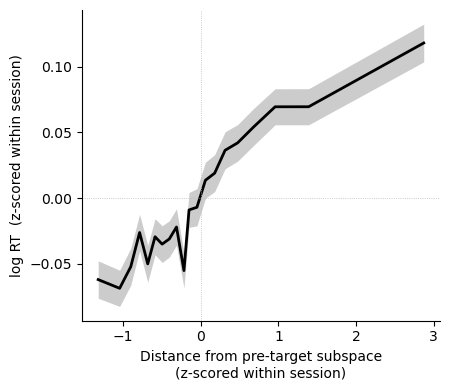

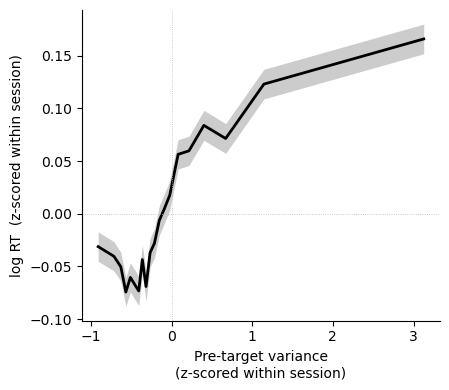

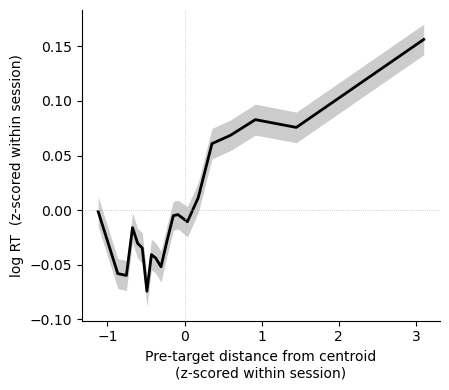

peak_dist_from_pre_subspace    LME beta=+0.0173 [+0.015, +0.01961] p=7.63e-49  (n=102635 trials, 143 sessions, 7 birds)
pre_var                        LME beta=+0.01985 [+0.01754, +0.02216] p=9.62e-64  (n=102635 trials, 143 sessions, 7 birds)
dist_from_centroid             LME beta=+0.0184 [+0.01609, +0.02071] p=5.44e-55  (n=102635 trials, 143 sessions, 7 birds)


In [20]:
df_trials_stab = per_trial_pretarget_stability(
    neural_trial_dicts, base_dir_pop_mat, modality='active', accuracy='correct', verbose=False)
df_trials_stab.to_csv(os.path.join(out_dir, "trial_pretarget_stability.csv"), index=False)

for value_col, pretty, fname in [
    ("peak_dist_from_pre_subspace", "Distance from pre-target subspace",  "J_dist_from_pre_subspace_vs_rt.svg"),
    ("pre_var",                     "Pre-target variance",               "Supp_pre_var_vs_rt.svg"),
    ("dist_from_centroid",          "Pre-target distance from centroid", "Supp_dist_from_centroid_vs_rt.svg"),
]:
    plot_continuous_metric_vs_rt(df_trials_stab, value_col=value_col, pretty=pretty, fname=fname)
    plt.show()

# LME stats (stats_rows also consumed by the master-stats cell)
stats_rows = [compute_pretarget_metric_stats(df_trials_stab, c)
              for c in ("peak_dist_from_pre_subspace", "pre_var", "dist_from_centroid")]
for s in stats_rows:
    print("%-30s LME beta=%+.4g [%+.4g, %+.4g] p=%.3g  (n=%d trials, %d sessions, %d birds)"
          % (s["metric"], s["lme_beta"], s["lme_ci_lo"], s["lme_ci_hi"], s["lme_p"],
             s["n_trials"], s["lme_n_sessions"], s["lme_n_birds"]))

## 12) Master stats CSV

In [22]:
master_rows = []

def add_row(section, metric, test, value, n=None, p=None,
             ci_low=None, ci_high=None, notes=""):
    master_rows.append({
        "section": section, "metric": metric, "test": test,
        "value": value, "n": n, "p": p,
        "ci_low": ci_low, "ci_high": ci_high, "notes": notes,
    })

c = df_dec_sess["frac_wrong_correct"].to_numpy()
i = df_dec_sess["frac_wrong_incorrect"].to_numpy()
d = i - c
n = len(d)
rng = np.random.default_rng(0)
boots = np.array([np.mean(rng.choice(d, size=n, replace=True))
                   for _ in range(10000)])
ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
res_w = wilcoxon(d, alternative="greater") if n >= 2 else None
res_t = ttest_rel(i, c, alternative="greater")
add_row("1_errors", "frac_wrong_correct",   "mean", float(c.mean()), n=n)
add_row("1_errors", "frac_wrong_incorrect", "mean", float(i.mean()), n=n)
add_row("1_errors", "delta_incorrect_minus_correct", "mean",
         float(d.mean()), n=n,
         ci_low=float(ci_lo), ci_high=float(ci_hi),
         notes="95% bootstrap CI on mean delta")
add_row("1_errors", "delta_incorrect_minus_correct", "paired_t_greater",
         float(res_t.statistic), n=n, p=float(res_t.pvalue))
if res_w is not None:
    add_row("1_errors", "delta_incorrect_minus_correct", "wilcoxon_greater",
             float(res_w.statistic), n=n, p=float(res_w.pvalue))
add_row("1_errors", "delta_incorrect_minus_correct", "cohens_d_paired",
         float(d.mean() / d.std(ddof=1)), n=n)

r = df_geom_sess["ratio"].to_numpy()
r = r[np.isfinite(r)]
n = len(r)
boot_med = np.array([np.median(rng.choice(r, size=n, replace=True))
                      for _ in range(10000)])
ci_med_lo, ci_med_hi = np.percentile(boot_med, [2.5, 97.5])
res_w = wilcoxon(r - 1.0, alternative="greater") if n >= 2 else None
res_t = ttest_1samp(r, popmean=1.0, alternative="greater")
add_row("2_ratio", "ratio_d_NC_mid_over_d_cue1_cue2", "median",
         float(np.median(r)), n=n,
         ci_low=float(ci_med_lo), ci_high=float(ci_med_hi),
         notes="95% bootstrap CI on median")
add_row("2_ratio", "fraction_sessions_ratio_gt_1", "fraction",
         float(np.mean(r > 1)), n=n)
if res_w is not None:
    add_row("2_ratio", "ratio_minus_1", "wilcoxon_greater",
             float(res_w.statistic), n=n, p=float(res_w.pvalue))
add_row("2_ratio", "ratio_minus_1", "one_sample_t_greater",
         float(res_t.statistic), n=n, p=float(res_t.pvalue))

for label, st in [("3_distance_active",  lme_da),
                  ("3_distance_passive", lme_dp)]:
    add_row(label, "delta_cued_minus_NC", "LME_beta", float(st["beta"]),
            n=int(st["n_sessions"]), p=float(st["p"]),
            ci_low=float(st["ci_lo"]), ci_high=float(st["ci_hi"]), notes=st["method"])
    add_row(label, "delta_cued_minus_NC", "wilcoxon", float(st["wilcoxon_W"]),
            n=int(st["n_sessions"]), p=float(st["wilcoxon_p"]))

section_labels = {
    'peak_dist_from_pre_subspace': '4_main_dist_from_pre_subspace',
    'pre_var':                     '4_supp_pre_var',
    'dist_from_centroid':          '4_supp_dist_from_centroid',
}
for s in stats_rows:
    sec = section_labels.get(s['metric'], '4_other')
    add_row(sec, f"{s['metric']}_vs_log_rt", "pooled_spearman_rho",
             float(s['pooled_rho']), n=int(s['n_trials']), p=float(s['pooled_p']))
    add_row(sec, f"{s['metric']}_vs_log_rt", "median_per_session_rho",
             float(s['median_per_session_rho']),
             n=int(s['n_sessions']),
             notes=f"positive in {s['n_pos_per_session']}/{s['n_sessions']} populations")
    add_row(sec, f"{s['metric']}_vs_log_rt", "wilcoxon_on_per_session_rho",
             float(s['wilcoxon_W_per_session']), n=int(s['n_sessions']),
             p=float(s['wilcoxon_p_per_session']))

master_df = pd.DataFrame(master_rows)
stats_csv_dir = f"{STATS_CSV_DIR}"
os.makedirs(stats_csv_dir, exist_ok=True)
master_path = os.path.join(stats_csv_dir, "4.1_all_stats_master.csv")
master_df.to_csv(master_path, index=False)
print(f"Wrote master stats CSV: {master_path}")
print(f"  {len(master_df)} rows, {master_df['section'].nunique()} sections")
print()
print(master_df.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

KeyError: 'n_sessions'